Channel gains: [ 0.1  1.   5.  10. ]
SEP values: [0.47088227 0.27440582 0.02489353 0.00123938]


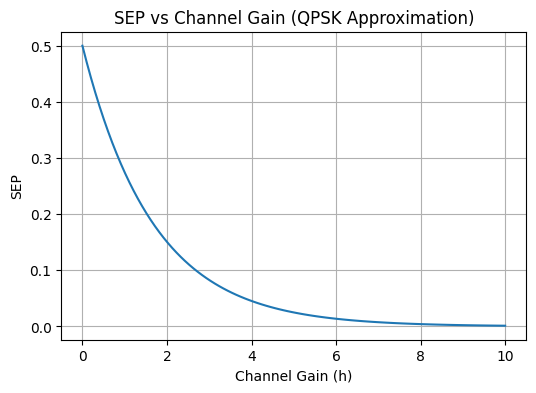

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants for QPSK (given)
# ===============================
C1 = 0.5
C2 = 0.6


# ===============================
# 1. Scalar SEP computation
# ===============================
def compute_sep(h, c1=C1, c2=C2):
    """
    Compute SEP for a single channel gain value.

    Parameters:
        h  : float (channel power gain)
        c1 : constant (default 0.5)
        c2 : constant (default 0.6)

    Returns:
        SEP value
    """
    return c1 * np.exp(-c2 * h)


# ===============================
# 2. Vectorized SEP computation
# ===============================
def compute_sep_vector(h_vec, c1=C1, c2=C2):
    """
    Compute SEP for a vector of channel gains.

    Parameters:
        h_vec : numpy array of shape (L,)

    Returns:
        numpy array of SEP values
    """
    return c1 * np.exp(-c2 * h_vec)


# ===============================
# 3. Batch SEP computation
# ===============================
def compute_sep_batch(H, c1=C1, c2=C2):
    """
    Compute SEP for batch input.

    Parameters:
        H : numpy array of shape (N, L)

    Returns:
        numpy array of shape (N, L)
    """
    return c1 * np.exp(-c2 * H)


# ===============================
# 4. Sanity Test
# ===============================
def test_sep():
    h_test = np.array([0.1, 1, 5, 10])
    sep_values = compute_sep_vector(h_test)

    print("Channel gains:", h_test)
    print("SEP values:", sep_values)


# ===============================
# 5. Visualization (Optional but useful)
# ===============================
def plot_sep_curve():
    h = np.linspace(0, 10, 100)
    sep = compute_sep_vector(h)

    plt.figure(figsize=(6, 4))
    plt.plot(h, sep)
    plt.xlabel("Channel Gain (h)")
    plt.ylabel("SEP")
    plt.title("SEP vs Channel Gain (QPSK Approximation)")
    plt.grid(True)
    plt.show()


# ===============================
# 6. Run test if executed directly
# ===============================
if __name__ == "__main__":
    test_sep()
    plot_sep_curve()

**SEP modeling**

In [3]:
import numpy as np

# ===============================
# GLOBAL CONSTANTS
# ===============================
C1 = 0.5
C2 = 0.6


# ===============================
# 1. SEP FUNCTION
# ===============================
def compute_sep(h):
    return C1 * np.exp(-C2 * h)


# ===============================
# 2. CHANNEL GENERATION
# ===============================
def generate_channel(L, mu_h, mu_g):

    # Exponential channel gains
    h = np.random.exponential(scale=mu_h, size=L)
    g = np.random.exponential(scale=mu_g, size=L)

    return h, g


# ===============================
# 3. ANTENNA SELECTION
# ===============================
def select_antenna(h, g, lam):

    sep = compute_sep(h)

    # Real antenna metrics
    metric_real = sep + lam * g

    # Virtual antenna (s = 0)
    metric_zero = C1

    metrics = np.concatenate([[metric_zero], metric_real])

    return np.argmin(metrics)


# ===============================
# 4. INTERFERENCE ESTIMATION
# ===============================
def estimate_interference(
    lam,
    Es,
    L,
    mu_h,
    mu_g,
    num_samples=3000
):

    g_selected = []

    for _ in range(num_samples):

        h, g = generate_channel(L, mu_h, mu_g)

        s = select_antenna(h, g, lam)

        if s == 0:
            g_selected.append(0.0)
        else:
            g_selected.append(g[s - 1])

    return Es * np.mean(g_selected)


# ===============================
# 5. FIND LAMBDA
# ===============================
def find_lambda(
    Es,
    I_ave,
    L,
    mu_h,
    mu_g,
    tol=1e-2
):

    lam_low = 0.0
    lam_high = 1.0

    # Expand upper bound
    while True:

        I_est = estimate_interference(
            lam_high,
            Es,
            L,
            mu_h,
            mu_g
        )

        if I_est < I_ave:
            break

        lam_high *= 2

        if lam_high > 1e6:
            print("WARNING: lambda too large")
            break

    # Bisection search
    for _ in range(40):

        lam_mid = (lam_low + lam_high) / 2

        I_est = estimate_interference(
            lam_mid,
            Es,
            L,
            mu_h,
            mu_g
        )

        if abs(I_est - I_ave) < tol:
            return lam_mid

        if I_est > I_ave:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    return lam_mid


# ===============================
# 6. DATASET GENERATION
# ===============================
def generate_dataset(
    N,
    L,
    Es,
    I_ave,
    mu_h,
    mu_g
):

    print("Finding lambda...")

    lam = find_lambda(
        Es,
        I_ave,
        L,
        mu_h,
        mu_g
    )

    print(f"Lambda found: {lam:.4f}")

    I_check = estimate_interference(
        lam,
        Es,
        L,
        mu_h,
        mu_g
    )

    print(
        f"Final interference: "
        f"{I_check:.4f} (target {I_ave})"
    )

    X = []
    y = []

    for _ in range(N):

        h, g = generate_channel(L, mu_h, mu_g)

        s = select_antenna(h, g, lam)

        features = np.concatenate([h, g, [I_ave]])

        X.append(features)
        y.append(s)

    return np.array(X), np.array(y), lam

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ===============================
# CONFIG
# ===============================
np.random.seed(42)
torch.manual_seed(42)

L = 2
Es = 30
mu_h = 9
mu_g = 7

I_values = [2, 4, 6, 8]
N_per_I = 3000


# ===============================
# 1. MULTI I_ave DATASET
# ===============================
def generate_multi_I_dataset(N_per_I, L, Es, I_values, mu_h, mu_g):
    X_all, y_all = [], []

    for I_ave in I_values:
        print(f"\nGenerating for I_ave = {I_ave}")
        X, y, _ = generate_dataset(N_per_I, L, Es, I_ave, mu_h, mu_g)
        X_all.append(X)
        y_all.append(y)

    X_all = np.vstack(X_all)
    y_all = np.hstack(y_all)

    return X_all, y_all


print("\nGenerating dataset...")
X, y = generate_multi_I_dataset(N_per_I, L, Es, I_values, mu_h, mu_g)


# ===============================
# 2. SHUFFLE DATASET
# ===============================
perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]


# ===============================
# 3. LOG TRANSFORM (IMPORTANT FIX)
# ===============================
h = X[:, :L]
g = X[:, L:2*L]
I = X[:, -1:]

X = np.concatenate([np.log1p(h), np.log1p(g), I], axis=1)


# ===============================
# 4. NORMALIZATION
# ===============================
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X = (X - X_mean) / X_std


# ===============================
# 5. TRAIN-TEST SPLIT
# ===============================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)


# ===============================
# 6. CLASS WEIGHTS (FIXED VERSION)
# ===============================
class_counts = np.bincount(y_train.numpy(), minlength=L+1).astype(np.float32)
class_weights = 1.0 / (class_counts + 1e-6)

# normalize by mean (not sum)
class_weights = class_weights / class_weights.mean()

class_weights = torch.tensor(class_weights, dtype=torch.float32)


# ===============================
# 7. MODEL (SLIGHTLY BIGGER)
# ===============================
class DNNClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)


input_size = 2 * L + 1
num_classes = L + 1

model = DNNClassifier(input_size, num_classes)


# ===============================
# 8. TRAINING SETUP
# ===============================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# LR scheduler (stabilizes late training)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

epochs = 150
batch_size = 128


# ===============================
# 9. TRAINING LOOP
# ===============================
print("\nTraining model...")

for epoch in range(epochs):

    perm = torch.randperm(X_train.size(0))
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]

    total_loss = 0

    for i in range(0, X_train_shuffled.size(0), batch_size):
        x_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


# ===============================
# 10. EVALUATION
# ===============================
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).sum().item() / y_test.size(0)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")


# ===============================
# 11. SAVE MODEL
# ===============================
torch.save(model.state_dict(), "model_L2.pth")
print("Model saved as model_L2.pth")
np.save("X_mean_L2.npy", X_mean)
np.save("X_std_L2.npy", X_std)


Generating dataset...

Generating for I_ave = 2
Finding lambda...
Lambda found: 0.6045
Final interference: 1.9781 (target 2)

Generating for I_ave = 4
Finding lambda...
Lambda found: 0.4082
Final interference: 4.0680 (target 4)

Generating for I_ave = 6
Finding lambda...
Lambda found: 0.3203
Final interference: 6.3436 (target 6)

Generating for I_ave = 8
Finding lambda...
Lambda found: 0.2814
Final interference: 7.6734 (target 8)

Training model...
Epoch [10/150], Loss: 3.6001
Epoch [20/150], Loss: 2.3260
Epoch [30/150], Loss: 1.8689
Epoch [40/150], Loss: 1.1489
Epoch [50/150], Loss: 0.5970
Epoch [60/150], Loss: 0.6477
Epoch [70/150], Loss: 0.3897
Epoch [80/150], Loss: 0.3164
Epoch [90/150], Loss: 0.2272
Epoch [100/150], Loss: 0.2046
Epoch [110/150], Loss: 0.2274
Epoch [120/150], Loss: 0.1566
Epoch [130/150], Loss: 0.1161
Epoch [140/150], Loss: 0.1147
Epoch [150/150], Loss: 0.0931

Test Accuracy: 98.83%
Model saved as model_L2.pth


**Data generation and Training**

I = 2
I = 4
I = 6
I = 8


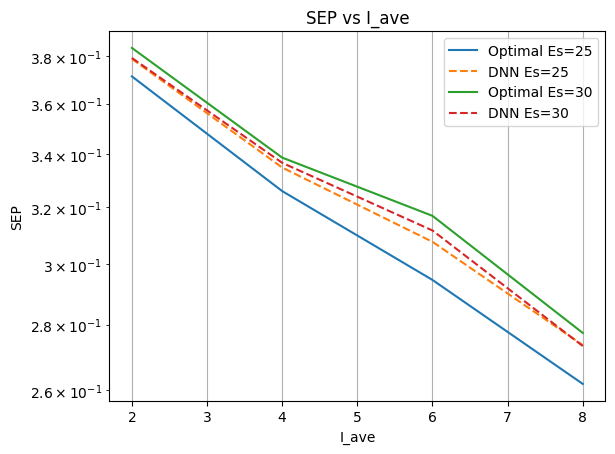

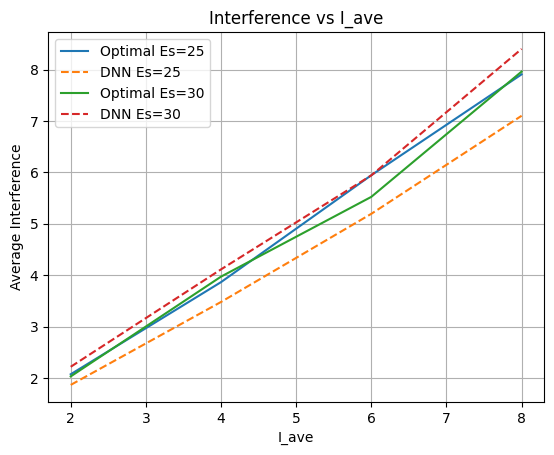

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ===============================
# MODEL (same as training)
# ===============================
class DNNClassifier(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_size, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 32), torch.nn.ReLU(),
            torch.nn.Linear(32, 16), torch.nn.ReLU(),
            torch.nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ===============================
# LOAD MODEL
# ===============================
def load_model(L, path):
    model = DNNClassifier(2*L+1, L+1)
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    return model


# ===============================
# LOAD NORMALIZATION (FIXED)
# ===============================
X_mean = np.load("X_mean_L4.npy")
X_std = np.load("X_std_L4.npy")


# ===============================
# DNN PREDICTION
# ===============================
def dnn_predict(model, x):
    x = (x - X_mean) / X_std
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        out = model(x)

    return torch.argmax(out).item()


# ===============================
# EVALUATION
# ===============================
def evaluate(model, L, Es, I_ave, mu_h, mu_g, N=3000):

    lam = find_lambda(Es, I_ave, L, mu_h, mu_g)

    sep_opt, sep_dnn = [], []
    g_opt, g_dnn = [], []

    for _ in range(N):
        h, g = generate_channel(L, mu_h, mu_g)

        # ---------- OPTIMAL ----------
        s_opt = select_antenna(h, g, lam)
        if s_opt == 0:
            sep_opt.append(0.5)
            g_opt.append(0)
        else:
            sep_opt.append(compute_sep(h[s_opt-1]))
            g_opt.append(g[s_opt-1])

        # ---------- DNN ----------
        x = np.concatenate([np.log1p(h), np.log1p(g), [I_ave]])
        s_dnn = dnn_predict(model, x)

        if s_dnn == 0:
            sep_dnn.append(0.5)
            g_dnn.append(0)
        else:
            sep_dnn.append(compute_sep(h[s_dnn-1]))
            g_dnn.append(g[s_dnn-1])

    return (
        np.mean(sep_opt),
        np.mean(sep_dnn),
        Es * np.mean(g_opt),
        Es * np.mean(g_dnn)
    )


# ===============================
# MAIN PLOTS
# ===============================
def main():
    mu_h, mu_g = 9, 7

    # SAME values as training (IMPORTANT)
    I_vals = [2, 4, 6, 8]

    L = 4
    model = load_model(L, "model_L4.pth")

    sep_opt_25, sep_dnn_25 = [], []
    sep_opt_30, sep_dnn_30 = [], []
    int_opt_25, int_dnn_25 = [], []
    int_opt_30, int_dnn_30 = [], []

    for I in I_vals:
        print(f"I = {I}")

        s1, s2, i1, i2 = evaluate(model, L, 25, I, mu_h, mu_g)
        sep_opt_25.append(s1)
        sep_dnn_25.append(s2)
        int_opt_25.append(i1)
        int_dnn_25.append(i2)

        s1, s2, i1, i2 = evaluate(model, L, 30, I, mu_h, mu_g)
        sep_opt_30.append(s1)
        sep_dnn_30.append(s2)
        int_opt_30.append(i1)
        int_dnn_30.append(i2)

    # ===============================
    # PLOT 1: SEP
    # ===============================
    plt.figure()
    plt.semilogy(I_vals, sep_opt_25, label="Optimal Es=25")
    plt.semilogy(I_vals, sep_dnn_25, "--", label="DNN Es=25")
    plt.semilogy(I_vals, sep_opt_30, label="Optimal Es=30")
    plt.semilogy(I_vals, sep_dnn_30, "--", label="DNN Es=30")

    plt.xlabel("I_ave")
    plt.ylabel("SEP")
    plt.title("SEP vs I_ave")
    plt.legend()
    plt.grid()
    plt.show()

    # ===============================
    # PLOT 2: INTERFERENCE
    # ===============================
    plt.figure()
    plt.plot(I_vals, int_opt_25, label="Optimal Es=25")
    plt.plot(I_vals, int_dnn_25, "--", label="DNN Es=25")
    plt.plot(I_vals, int_opt_30, label="Optimal Es=30")
    plt.plot(I_vals, int_dnn_30, "--", label="DNN Es=30")

    plt.xlabel("I_ave")
    plt.ylabel("Average Interference")
    plt.title("Interference vs I_ave")
    plt.legend()
    plt.grid()
    plt.show()


# ===============================
# RUN
# ===============================
if __name__ == "__main__":
    main()

**Evaluation Plots**


Evaluating L = 2
L=2, I=2, SEP=0.4169
L=2, I=4, SEP=0.3817
L=2, I=6, SEP=0.3511
L=2, I=8, SEP=0.3378

Evaluating L = 4
L=4, I=2, SEP=0.3706
L=4, I=4, SEP=0.3465
L=4, I=6, SEP=0.3035
L=4, I=8, SEP=0.2731


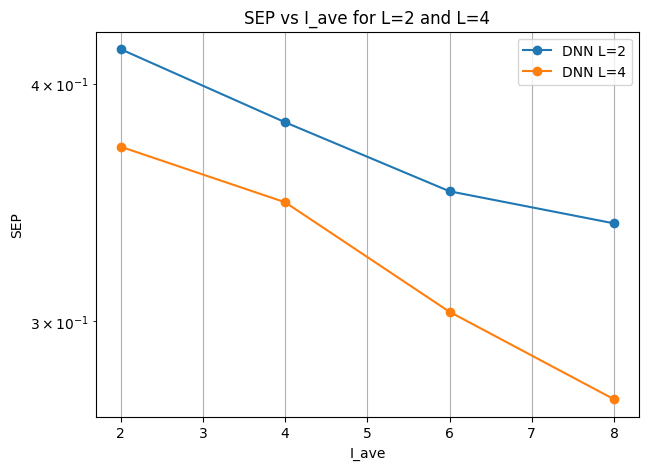

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# =====================================================
# Uses functions already defined in notebook:
# compute_sep
# generate_channel
# select_antenna
# find_lambda
# =====================================================


# ===============================
# MODEL
# ===============================
class DNNClassifier(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_size, 64),
            torch.nn.ReLU(),

            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),

            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),

            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),

            torch.nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ===============================
# LOAD MODEL
# ===============================
def load_model(L):

    model = DNNClassifier(2*L + 1, L + 1)

    model.load_state_dict(
        torch.load(
            f"model_L{L}.pth",
            map_location="cpu"
        )
    )

    model.eval()

    return model


# ===============================
# DNN PREDICTION
# ===============================
def dnn_predict(model, x, mean, std):

    x = (x - mean) / std

    x = torch.tensor(
        x,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():
        out = model(x)

    return torch.argmax(out).item()


# ===============================
# EVALUATION
# ===============================
def evaluate_sep(
    model,
    L,
    Es,
    I_ave,
    mu_h,
    mu_g,
    mean,
    std,
    N=3000
):

    lam = find_lambda(
        Es,
        I_ave,
        L,
        mu_h,
        mu_g
    )

    sep_dnn = []

    for _ in range(N):

        h, g = generate_channel(L, mu_h, mu_g)

        x = np.concatenate([
            np.log1p(h),
            np.log1p(g),
            [I_ave]
        ])

        s = dnn_predict(
            model,
            x,
            mean,
            std
        )

        if s == 0:
            sep_dnn.append(0.5)
        else:
            sep_dnn.append(
                compute_sep(h[s-1])
            )

    return np.mean(sep_dnn)


# ===============================
# PLOT 3
# ===============================
mu_h = 9
mu_g = 7
Es = 30

I_vals = [2, 4, 6, 8]

plt.figure(figsize=(7,5))

for L in [2, 4]:

    print(f"\nEvaluating L = {L}")

    # Load model
    model = load_model(L)

    # Load normalization
    mean = np.load(f"X_mean_L{L}.npy")
    std = np.load(f"X_std_L{L}.npy")

    sep_vals = []

    for I in I_vals:

        sep = evaluate_sep(
            model,
            L,
            Es,
            I,
            mu_h,
            mu_g,
            mean,
            std
        )

        sep_vals.append(sep)

        print(f"L={L}, I={I}, SEP={sep:.4f}")

    plt.semilogy(
        I_vals,
        sep_vals,
        marker='o',
        label=f"DNN L={L}"
    )

plt.xlabel("I_ave")
plt.ylabel("SEP")
plt.title("SEP vs I_ave for L=2 and L=4")
plt.grid(True)
plt.legend()
plt.show()